# MAQT & Proposition-2 Quantities: $F_{\mathrm{in}}$, $F_{\mathrm{out}}$, $\varepsilon^\star$
## UNSW-NB15 | Reuse Day-16 Checkpoint + $L_\varphi$ | Batch Size 64 | LR 0.05
## Target (y) = "label_multiclass" | Data Reupload = 2

### Scope:
This notebook measures **Proposition-2 geometry** on the frozen MAQT encoder:
- load $\theta^\star$, class prototypes $\rho_c$, and $L_\varphi$
- encode known-test / zero-day samples to post-channel states $\rho(x)=\Lambda_p(U(\theta)|\psi(x)\rangle\langle\psi(x)|U(\theta)^\dagger)$
- report $F_{\mathrm{in}}$, $F_{\mathrm{out}}$, gap $\Delta$, and predicted budget $\varepsilon^\star$

### To Implement:
$$
\varepsilon^\star
= \frac{(1-F_{\mathrm{out}}) - \sqrt{1-F_{\mathrm{in}}^{2}}}{2(1-p)\,L_\varphi}
= \frac{\Delta}{2(1-p)\,L_\varphi}
$$

## Setup

In [1]:
import pennylane as qp
from pennylane import numpy as np
import torch

import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import time

In [2]:
from scripts.constants import (
    DEFAULT_LR, DEFAULT_BATCH_SIZE,
    DEFAULT_LAMBDA1, DEFAULT_LAMBDA2, DEFAULT_NOISE_RATE,
    DEFAULT_CF, DEFAULT_DELTA, DEFAULT_EPS,
)
from scripts.data import (
    capped_sample,
    load_split,
    plot_class_balance_pie,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.train import train_maqt
from scripts.utils import get_torch_device, to_np_y, to_torch_batch_x
from scripts.logging import write_history_log
from scripts.prototypes import prototype_summary
from scripts.quantum_metrics import (
    fidelity,
    max_fidelity_to_prototypes,
    stack_prototypes,
)

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: UNSW-NB15

In [4]:
NOTEBOOK_NAME = "18.fin-fout-epsstar_unsw-nb15"
DAY16_NOTEBOOK = "16.estimate-lipschitz_unsw-nb15"
dataset = "UNSW-NB15"
split_prefix = "q8"
target_col = "label_multiclass"
data_path = f"data/{dataset}/quantum"

In [5]:
df = pd.read_parquet(f"{data_path}/{split_prefix}_train.parquet")
df

,rate_dst,iat,rate,rate_src,duration,dst_bytes,conn_state,dst_pkts,label_multiclass,label_binary,label_family
0,2.660748,1.000199,1.193106,1.289150,1.240526,2.600926,3.141593,2.190781,Exploits,1,exploits
1,1.300715,1.148865,0.717575,1.401026,0.207269,0.850290,0.374600,0.370983,Normal,0,benign
2,0.000000,0.002482,2.641954,2.489562,0.000007,0.000000,0.168227,0.000000,Generic,1,generic
3,1.547429,1.337109,0.657683,1.161471,0.572600,1.232307,3.141593,0.809729,Normal,0,benign
4,2.342302,0.643438,1.282489,1.506876,0.034630,1.447465,3.141593,0.741966,Normal,0,benign
...,...,...,...,...,...,...,...,...,...,...,...
71089,1.413310,1.351137,0.614096,1.217883,0.610868,1.118026,3.141593,0.741966,Exploits,1,exploits
71090,1.808522,1.157237,0.776405,1.294835,0.348747,1.380490,3.141593,0.741966,DoS,1,dos
71091,2.636567,0.979324,1.179932,1.310244,0.758969,2.410352,3.141593,1.868532,Exploits,1,exploits
71092,1.803881,0.954620,0.931850,1.601995,0.431998,1.412047,3.141593,1.028084,Exploits,1,exploits


In [6]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,rate_dst,iat,rate,rate_src,duration,dst_bytes,conn_state,dst_pkts,label_multiclass,label_binary,label_family
0,2.660748,1.000199,1.193106,1.289150,1.240526,2.600926,3.141593,2.190781,Exploits,1,exploits
1,1.300715,1.148865,0.717575,1.401026,0.207269,0.850290,0.374600,0.370983,Normal,0,benign
2,0.000000,0.002482,2.641954,2.489562,0.000007,0.000000,0.168227,0.000000,Generic,1,generic
3,1.547429,1.337109,0.657683,1.161471,0.572600,1.232307,3.141593,0.809729,Normal,0,benign
4,2.342302,0.643438,1.282489,1.506876,0.034630,1.447465,3.141593,0.741966,Normal,0,benign
...,...,...,...,...,...,...,...,...,...,...,...
71089,1.413310,1.351137,0.614096,1.217883,0.610868,1.118026,3.141593,0.741966,Exploits,1,exploits
71090,1.808522,1.157237,0.776405,1.294835,0.348747,1.380490,3.141593,0.741966,DoS,1,dos
71091,2.636567,0.979324,1.179932,1.310244,0.758969,2.410352,3.141593,1.868532,Exploits,1,exploits
71092,1.803881,0.954620,0.931850,1.601995,0.431998,1.412047,3.141593,1.028084,Exploits,1,exploits


In [7]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['Analysis',
 'Backdoor',
 'DoS',
 'Exploits',
 'Fuzzers',
 'Generic',
 'Normal',
 'Reconnaissance']

In [8]:
# load full dataset (known classes only)
X_train_full, y_train_full = load_split(data_path, f"{split_prefix}_train", target_col, class_names)
X_test, y_test = load_split(data_path, f"{split_prefix}_test", target_col, class_names)

In [9]:
# check shape
[X_train_full.shape, y_train_full.shape, X_test.shape, y_test.shape]

[(71094, 8), (71094,), (10086, 8), (10086,)]

## EDA (Before Subset)

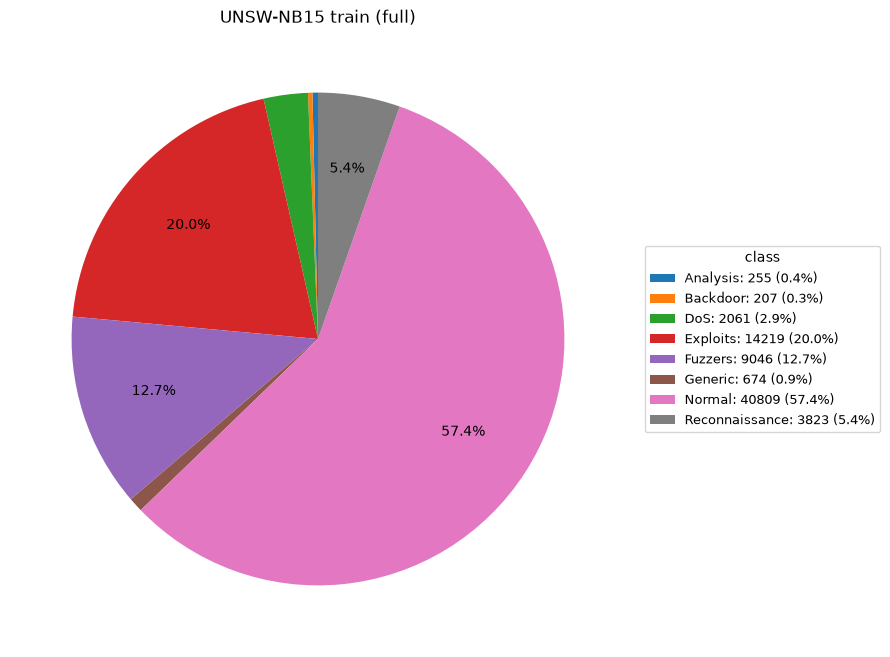

In [10]:
# pie chart
_ = plot_class_balance_pie(y_train_full, class_names, title=f"{dataset} train (full)")
plt.show()

## Data Subset

In [11]:
SUBSET = True  # set to False for the full dataset
SEED = 42
PER_CLASS_CAP = 400  # matches Day-16 UNSW-NB15 protocol

In [12]:
if SUBSET is True:
    X_train, y_train = capped_sample(X_train_full, y_train_full, PER_CLASS_CAP, seed=SEED)
else:
    X_train, y_train = X_train_full, y_train_full

# check shape
[X_train.shape, y_train.shape]

[(2862, 8), (2862,)]

## EDA (After Subset)

In [13]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"number of classes: {num_classes}")
print(f"number of qubits: {num_qubits}")

number of classes: 8
number of qubits: 8


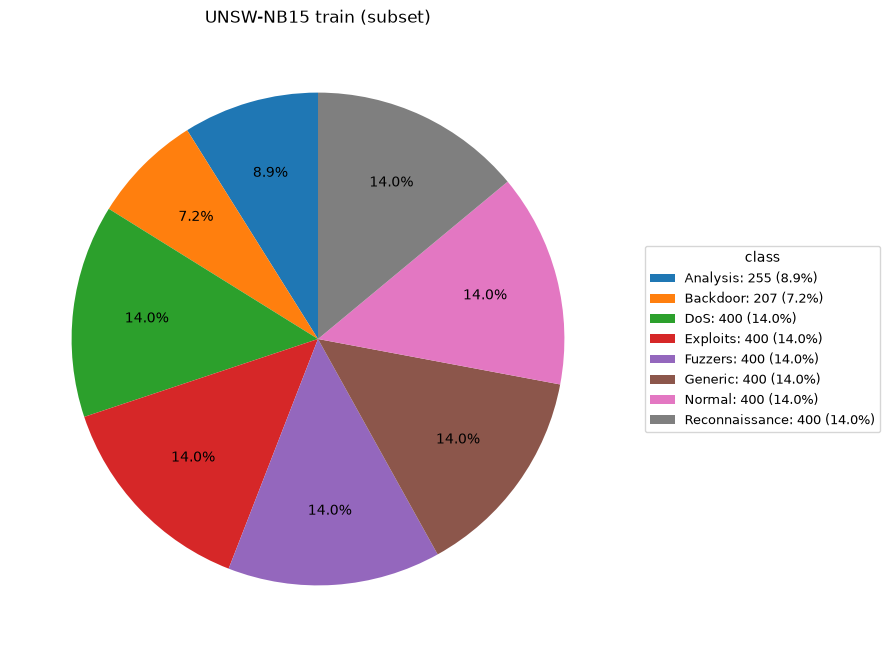

In [14]:
# pie chart
_ = plot_class_balance_pie(y_train, class_names, title=f"{dataset} train (subset)" if SUBSET else f"{dataset} train")
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [15]:
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE

In [16]:
# initialize devices
device = get_torch_device()
dev = create_quantum_device(num_qubits) # or dev = qp.device("default.mixed", wires=num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

## Load Day-16 Encoder + $L_\varphi$

This notebook reuses the Day-16 MAQT checkpoint ($\theta^\star$, prototypes) and the published $L_\varphi$ artifact.

Set `LOAD_CHECKPOINT = False` only to retrain as a fallback.

In [17]:
LOAD_CHECKPOINT = True
CHECKPOINT_CANDIDATES = [
    Path("artifacts") / dataset / f"{DAY16_NOTEBOOK}-checkpoint.pt",
]
LPHI_CANDIDATES = [
    Path("artifacts") / dataset / f"{DAY16_NOTEBOOK}-lphi.pt",
]

epochs = 10
batch_size = DEFAULT_BATCH_SIZE
lr = DEFAULT_LR
lambda1 = DEFAULT_LAMBDA1
lambda2 = DEFAULT_LAMBDA2
Cf = DEFAULT_CF

In [18]:
ckpt_path = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
lphi_path = next((p for p in LPHI_CANDIDATES if p.exists()), None)
history = {}
head = None

# use model checkpoint if loading is enabled and a valid file exists
if LOAD_CHECKPOINT and ckpt_path is not None:
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    theta_star = ckpt["theta"].to(device)
    if not isinstance(theta_star, torch.nn.Parameter):
        theta_star = torch.nn.Parameter(theta_star)
    prototypes = {int(k): v.to(device) for k, v in ckpt["prototypes"].items()}
    noise_rate = float(ckpt.get("noise_rate", noise_rate))
    num_layers = int(ckpt.get("num_layers", num_layers))

    # rebuild circuit if checkpoint meta differs
    forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)
    print(f"loaded checkpoint: {ckpt_path}")
    print(f"theta shape: {tuple(theta_star.shape)} | prototypes: {len(prototypes)}")

# train from scratch if checkpoint loading is disabled or no checkpoint exists
else:
    if LOAD_CHECKPOINT:
        print("checkpoint not found; falling back to MAQT train")
    theta, head, prototypes, ema_protos, history = train_maqt(
        X_train, y_train,
        n_classes=num_classes,
        n_qubits=num_qubits,
        n_layers=num_layers,
        forward_circuit=forward_circuit,
        device=device,
        epochs=epochs,
        lr=lr,
        batch_size=batch_size,
        lambda1_max=lambda1,
        lambda2_max=lambda2,
        use_weighted_sampler=True,
    )
    theta_star = theta
    print(f"trained encoder: theta shape={tuple(theta_star.shape)} | prototypes={len(prototypes)}")

loaded checkpoint: artifacts/UNSW-NB15/16.estimate-lipschitz_unsw-nb15-checkpoint.pt
theta shape: (2, 8, 3) | prototypes: 8


In [19]:
# load Day-16 L_phi (required for eps*)
if lphi_path is not None:
    lphi_art = torch.load(lphi_path, map_location="cpu", weights_only=False)
    L_phi = float(lphi_art["L_phi"])
    L_phi_percentile = float(lphi_art.get("L_phi_percentile", 95.0))
    print(f"loaded L_phi from: {lphi_path}")
    print(f"L_phi (p{L_phi_percentile:g}) = {L_phi:.4f}")
else:
    raise FileNotFoundError(
        f"Day-16 L_phi artifact not found under artifacts/{dataset}/. "
        "Run 16.estimate-lipschitz_ciciot2023.ipynb first."
    )

loaded L_phi from: artifacts/UNSW-NB15/16.estimate-lipschitz_unsw-nb15-lphi.pt
L_phi (p95) = 2.7609


## Load Zero-Day Split

$F_{\mathrm{out}}$ uses max fidelity of each zero-day state to the known prototypes only.

In [20]:
df_zero = pd.read_parquet(f"{data_path}/{split_prefix}_zeroday.parquet")
df_zero

,rate_dst,iat,rate,rate_src,duration,dst_bytes,conn_state,dst_pkts,label_multiclass,label_binary,label_family
0,1.497197,1.238243,0.711284,1.268586,0.440160,1.118026,3.141593,0.741966,Shellcode,1,shellcode
1,1.611438,0.967008,0.891077,1.332650,0.202892,1.065209,3.141593,0.657101,Shellcode,1,shellcode
2,1.340432,1.449052,0.531993,1.125236,0.790428,1.118026,3.141593,0.741966,Shellcode,1,shellcode
3,1.587506,1.017750,0.862374,1.331020,0.227033,1.065209,3.141593,0.657101,Shellcode,1,shellcode
4,1.529198,1.046971,0.792809,1.251174,0.296308,1.065209,3.141593,0.657101,Shellcode,1,shellcode
...,...,...,...,...,...,...,...,...,...,...,...
1211,0.000000,0.002756,2.617996,2.555055,0.000008,0.000000,0.168227,0.000000,Shellcode,1,shellcode
1212,2.485675,1.241960,0.974775,1.176774,1.472729,2.491320,3.141593,1.982915,Worms,1,worms
1213,1.441478,1.218249,0.689473,1.321986,0.431978,1.065209,3.141593,0.657101,Worms,1,worms
1214,1.309343,1.513082,0.497839,1.042796,0.875412,1.118026,3.141593,0.741966,Shellcode,1,shellcode


In [21]:
feature_cols = [c for c in df_zero.columns if not c.startswith("label")]
X_zero_full = df_zero[feature_cols].values.astype(np.float32)

ZERO_SUBSET = True
ZERO_CAP = 2000  # set ZERO_SUBSET=False to use all zero-day rows

if ZERO_SUBSET:
    rng = np.random.default_rng(SEED)
    n_take = min(ZERO_CAP, len(X_zero_full))
    idx = rng.choice(len(X_zero_full), size=n_take, replace=False)
    X_zero = X_zero_full[idx]
else:
    X_zero = X_zero_full

print(f"zero-day rows: {len(X_zero_full)} | using: {len(X_zero)}\n")
if target_col in df_zero.columns:
    print("held-out labels:")
    print()
    print(df_zero[target_col].value_counts())

zero-day rows: 1216 | using: 1216

held-out labels:

label_multiclass
Shellcode    1062
Worms         154
Name: count, dtype: int64


## Proposition 2: $F_{\mathrm{in}}$, $F_{\mathrm{out}}$, $\varepsilon^\star$

### 1. Definitions

For each sample, encode $x \rightarrow \rho(x)$ (post-channel), then compare it to known-class prototypes $\{\rho_c\}_{c\in\mathcal{K}}$.

#### 1A. Per-sample fidelities

- **Own-prototype fidelity (known samples only, true label $y$)**: Answers how close this known sample is to its own class prototype:
  $$
  F_{\mathrm{own}}(x)=F\big(\rho(x),\,\rho_{y(x)}\big)
  $$

- **Nearest-prototype fidelity (any sample)**: Answers how close this sample is to the closest known prototype:
  $$
  F_{\max}(x)=\max_{c\in\mathcal{K}} F\big(\rho(x),\,\rho_c\big)
  $$

#### 1B. Scalars

- **$F_{\mathrm{in}}$ (known concentration)**: from known-test $F_{\mathrm{own}}$ values, the worst known sample (least like its own prototype):
  $$
  F_{\mathrm{in}}=\min_x F_{\mathrm{own}}(x)
  $$

- **$F_{\mathrm{out}}$ (zero-day separation)**: from zero-day $F_{\max}$ values, the worst zero-day (most like some known prototype):
  $$
  F_{\mathrm{out}}=\max_z F_{\max}(z)
  $$

- **$(1−\beta)$-quantile of $F_{\mathrm{out}}$**:
  $$
  F_{\mathrm{out}}^{(\beta)}
  = Q_{1-\beta}\big(\{F_{\max}(z):z\in Z\}\big)
  $$

### 2. Assumptions

1. **Lipschitz encoder**: There exists $L_\varphi$ such that for all $x,x'$,
$$
D_{\mathrm{tr}}\big(|\psi(x)\rangle\langle\psi(x)|,\,|\psi(x')\rangle\langle\psi(x')|\big)
\le L_\varphi\,\|x-x'\|_2.
$$
    - A bounded input change moves the encoded state by a bounded amount.
    - Budget is in $\ell_2$; FGSM is usually $\ell_\infty$.
    - Convert with $\|\delta\|_2\le\sqrt{d}\,\|\delta\|_\infty$ ($d=8\Rightarrow\approx 2.83\,\varepsilon_\infty$).
2. **Known samples are concentrated**: Every known-class sample satisfies $F_{\max}(x)\ge F_{\mathrm{in}}$: each known sample is at least this close in fidelity to its nearest prototype.
3. **Zero-day samples are separated**: Every zero-day sample $z$ satisfies $F_{\max}(z)\le F_{\mathrm{out}}$, with $F_{\mathrm{out}}<F_{\mathrm{in}}$.
4. **Where fidelities are measured**: $F_{\mathrm{in}}$ / $F_{\mathrm{out}}$ are measured on the post-channel states $𝜌(𝑥)$ at the same $p$ used at inference.
5. **Separability precondition**: The distance gap is positive:
$$
\Delta := (1-F_{\mathrm{out}}) - \sqrt{1-F_{\mathrm{in}}^2} > 0
$$
    - Stronger than $F_{\mathrm{in}}>F_{\mathrm{out}}$; must be checked empirically per dataset.

### 3. Intuition

| Symbol | Who | Meaning | Want |
|--------|-----|---------|------|
| $F_{\mathrm{in}}$ | known | farthest known from its own proto | high |
| $F_{\mathrm{out}}$ | zero-day | closest zero-day to any known proto | low |

Proposition-2 needs:
- $F_{\mathrm{out}}<F_{\mathrm{in}}$ measured on post-channel states $ρ(x)$ at the same $p$ used at inference.
- The stronger gap, $\Delta>0$.

### 4. Distance Maps (Opposite Fuchs–van de Graaf Sides)
$$
d_{\mathrm{in}}=\sqrt{1-F_{\mathrm{in}}^{2}},\qquad
d_{\mathrm{out}}=1-F_{\mathrm{out}},\qquad
\Delta=d_{\mathrm{out}}-d_{\mathrm{in}}.
$$
$$
\varepsilon^\star=\frac{\Delta}{2(1-p)\,L_\varphi}
\quad\text{requires (A5): }\Delta>0.
$$

### 5. Fidelity Convention

- `scripts.quantum_metrics.fidelity` and `scripts.quantum_metrics.max_fidelity_to_prototypes` already return non-squared fidelity.
- Proposition-2 uses the *non-squared* $F=\mathrm{tr}\sqrt{\sqrt{\rho}\sigma\sqrt{\rho}}$.
- Use those values directly.

In [22]:
# measurement knobs
p = float(noise_rate)
BETA = 0.05  # 95th percentile, quantile-relaxed, F_out # See Theory, 3.5: A quantile-relaxed version

print(f"dataset : {dataset}")
print(f"p / L_phi : {p} / {L_phi:.4f}")
print(f"n_test (known): {len(to_np_y(y_test))}")
print(f"n_zero: {len(X_zero)}")
print(f"beta (quantile F_out): {BETA}")

dataset : UNSW-NB15
p / L_phi : 0.01 / 2.7609
n_test (known): 10086
n_zero: 1216
beta (quantile F_out): 0.05


In [23]:
def collect_known_fidelities(X, y, theta, prototypes, forward_circuit, device, batch_size):
    """
    Return non-squared F_own and F_max on known-labeled samples.
    """
    y_np = to_np_y(y).astype(int)
    class_ids, proto_stack = stack_prototypes(prototypes, device=device)
    id_to_pos = {c: i for i, c in enumerate(class_ids)}

    f_own_list, f_max_list = [], []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            x_chunk = to_torch_batch_x(X[i:i + batch_size], device=device)
            _, rho_chunk = forward_circuit(x_chunk, theta)
            y_chunk = y_np[i:i + batch_size]

            f_max_batch = max_fidelity_to_prototypes(rho_chunk, proto_stack)
            for j in range(rho_chunk.shape[0]):
                c = int(y_chunk[j])
                if c not in id_to_pos:
                    continue
                f_own_val = fidelity(rho_chunk[j], prototypes[c])
                f_own_list.append(float(f_own_val.item() if torch.is_tensor(f_own_val) else f_own_val))
                f_max_list.append(float(f_max_batch[j].item()))
    return np.asarray(f_own_list, dtype=np.float64), np.asarray(f_max_list, dtype=np.float64)


def collect_zeroday_fmax(X, theta, prototypes, forward_circuit, device, batch_size):
    """
    Return non-squared F_max of zero-day samples vs known prototypes only.
    """
    _, proto_stack = stack_prototypes(prototypes, device=device)
    f_max_list = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            x_chunk = to_torch_batch_x(X[i:i + batch_size], device=device)
            _, rho_chunk = forward_circuit(x_chunk, theta)
            f_max_batch = max_fidelity_to_prototypes(rho_chunk, proto_stack)
            f_max_list.extend([float(v) for v in f_max_batch.detach().cpu().numpy()])
    return np.asarray(f_max_list, dtype=np.float64)


def prop2_gap(F_in, F_out):
    """
    Delta and eps* ingredients from non-squared fidelities.
    """
    d_in = float(np.sqrt(max(0.0, 1.0 - F_in ** 2)))
    d_out = float(1.0 - F_out)
    delta = d_out - d_in
    return d_in, d_out, delta


def eps_star(delta, p, L_phi):
    """
    Proposition-2 predicted separable budget from distance gap, noise rate, and L_phi.
    """
    denom = 2.0 * (1.0 - p) * L_phi
    if denom <= 0:
        return float("nan")
    return float(delta / denom)

In [24]:
t0 = time.time()
f_own, f_max_known = collect_known_fidelities(
    X_test, y_test, theta_star, prototypes, forward_circuit, device, batch_size
)
f_max_zero = collect_zeroday_fmax(
    X_zero, theta_star, prototypes, forward_circuit, device, batch_size
)
elapsed = time.time() - t0
print(f"collected fidelities in {elapsed:.1f}s")
print(f"n_known used: {len(f_own)} | n_zero used: {len(f_max_zero)}")

collected fidelities in 2243.3s
n_known used: 10086 | n_zero used: 1216


In [25]:
# convert to non-squared F is done by scripts v2.2

# F_in: fidelity-to-own-prototype (worst-case min + summaries)
F_in = float(np.min(f_own))
F_in_mean = float(np.mean(f_own))
F_in_p05 = float(np.percentile(f_own, 5))
F_in_p50 = float(np.percentile(f_own, 50))

# reference: theory text also discusses F_max concentration
F_in_max_min = float(np.min(f_max_known))

# F_out: max fidelity for zero-day (worst-case + quantile-relaxed)
F_out = float(np.max(f_max_zero))
F_out_beta = float(np.quantile(f_max_zero, 1.0 - BETA))
F_out_mean = float(np.mean(f_max_zero))
F_out_p50 = float(np.percentile(f_max_zero, 50))

d_in, d_out, Delta = prop2_gap(F_in, F_out)
d_in_b, d_out_b, Delta_beta = prop2_gap(F_in, F_out_beta)

eps_star_wc = eps_star(Delta, p, L_phi)
eps_star_beta = eps_star(Delta_beta, p, L_phi)

sep_ok = Delta > 0
sep_ok_beta = Delta_beta > 0

print("=== Proposition-2 quantities (non-squared F) ===")
print(f"F_in  (min own-proto)     : {F_in:.6f}")
print(f"F_in  (mean / p05 / p50)  : {F_in_mean:.6f} / {F_in_p05:.6f} / {F_in_p50:.6f}")
print(f"F_in  (min F_max, ref)    : {F_in_max_min:.6f}")
print(f"F_out (max F_max zero)    : {F_out:.6f}")
print(f"F_out^(beta={BETA:g})     : {F_out_beta:.6f}")
print(f"F_out (mean / p50)        : {F_out_mean:.6f} / {F_out_p50:.6f}")
print()
print(f"d_in = sqrt(1-F_in^2)     : {d_in:.6f}")
print(f"d_out = 1-F_out           : {d_out:.6f}")
print(f"Delta = d_out - d_in      : {Delta:.6f}  | (A5) Delta>0? {sep_ok}")
print(f"eps* (worst-case)         : {eps_star_wc:.6f}")
print()
print(f"Delta^(beta)              : {Delta_beta:.6f}  | (A5') Delta>0? {sep_ok_beta}")
print(f"eps*^(beta)               : {eps_star_beta:.6f}")
print(f"F_in > F_out?             : {F_in > F_out}")

=== Proposition-2 quantities (non-squared F) ===
F_in  (min own-proto)     : 0.127587
F_in  (mean / p05 / p50)  : 0.716588 / 0.385794 / 0.723806
F_in  (min F_max, ref)    : 0.159203
F_out (max F_max zero)    : 1.000000
F_out^(beta=0.05)     : 0.998970
F_out (mean / p50)        : 0.818277 / 0.938071

d_in = sqrt(1-F_in^2)     : 0.991827
d_out = 1-F_out           : 0.000000
Delta = d_out - d_in      : -0.991827  | (A5) Delta>0? False
eps* (worst-case)         : -0.181435

Delta^(beta)              : -0.990797  | (A5') Delta>0? False
eps*^(beta)               : -0.181246
F_in > F_out?             : False


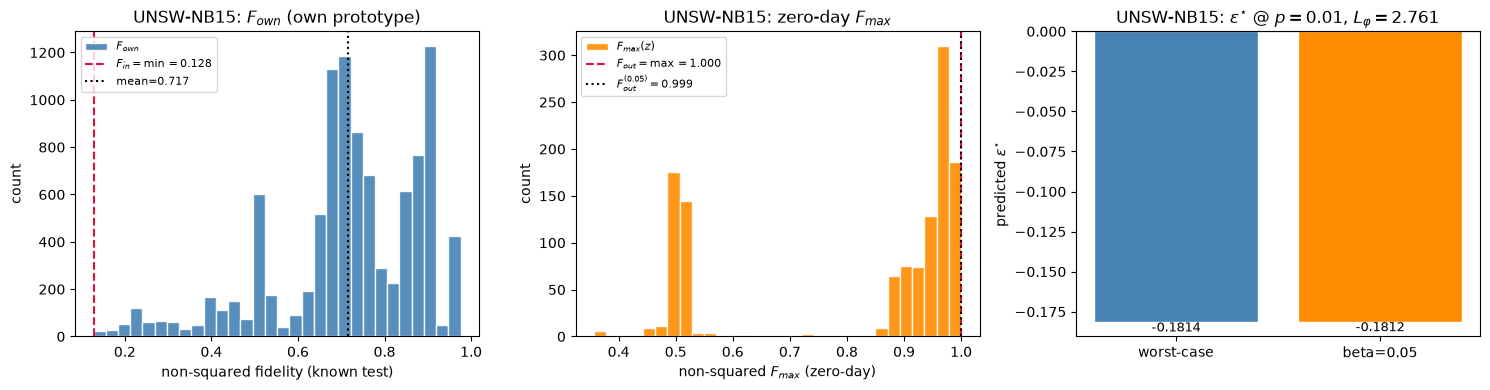

In [26]:
# plots: fidelity distributions + eps* summary
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(f_own, bins=30, color="steelblue", edgecolor="white", alpha=0.9, label=r"$F_{own}$")
axes[0].axvline(F_in, color="crimson", linestyle="--", label=fr"$F_{{in}}=\min={F_in:.3f}$")
axes[0].axvline(F_in_mean, color="black", linestyle=":", label=fr"mean={F_in_mean:.3f}")
axes[0].set_xlabel(r"non-squared fidelity (known test)")
axes[0].set_ylabel("count")
axes[0].set_title(rf"{dataset}: $F_{{own}}$ (own prototype)")
axes[0].legend(fontsize=8)

axes[1].hist(f_max_zero, bins=30, color="darkorange", edgecolor="white", alpha=0.9, label=r"$F_{max}(z)$")
axes[1].axvline(F_out, color="crimson", linestyle="--", label=fr"$F_{{out}}=\max={F_out:.3f}$")
axes[1].axvline(F_out_beta, color="black", linestyle=":", label=fr"$F_{{out}}^{{({BETA:g})}}={F_out_beta:.3f}$")
axes[1].set_xlabel(r"non-squared $F_{max}$ (zero-day)")
axes[1].set_ylabel("count")
axes[1].set_title(rf"{dataset}: zero-day $F_{{max}}$")
axes[1].legend(fontsize=8)

axes[2].bar(
    ["worst-case", fr"beta={BETA:g}"],
    [eps_star_wc, eps_star_beta],
    color=["steelblue", "darkorange"],
    edgecolor="white",
)
axes[2].axhline(0.0, color="black", linewidth=0.8)
axes[2].set_ylabel(r"predicted $\varepsilon^{\star}$")
axes[2].set_title(rf"{dataset}: $\varepsilon^{{\star}}$ @ $p={p:g}$, $L_{{\varphi}}={L_phi:.3f}$")
for i, v in enumerate([eps_star_wc, eps_star_beta]):
    axes[2].text(i, v, f"{v:.4f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)

plt.tight_layout()
plt.show()

In [27]:
prop2_df = pd.DataFrame({
    "quantity": [
        "F_in (min own-proto)",
        "F_in_mean",
        "F_in_p05",
        "F_in_p50",
        "F_in_ref (min F_max known)",
        "F_out (max F_max zero)",
        f"F_out_beta (q={1.0-BETA:g})",
        "F_out_mean",
        "d_in",
        "d_out",
        "Delta",
        "eps_star",
        "Delta_beta",
        "eps_star_beta",
        "A5_Delta_gt_0",
        "A5_beta_Delta_gt_0",
        "F_in_gt_F_out",
        "p",
        "L_phi",
        "n_known",
        "n_zero",
    ],
    "value": [
        F_in, F_in_mean, F_in_p05, F_in_p50, F_in_max_min,
        F_out, F_out_beta, F_out_mean,
        d_in, d_out, Delta, eps_star_wc,
        Delta_beta, eps_star_beta,
        sep_ok, sep_ok_beta, bool(F_in > F_out),
        p, L_phi, len(f_own), len(f_max_zero),
    ],
})
prop2_df

,quantity,value
0,F_in (min own-proto),0.127587
1,F_in_mean,0.716588
2,F_in_p05,0.385794
3,F_in_p50,0.723806
4,F_in_ref (min F_max known),0.159203
5,F_out (max F_max zero),1.0
6,F_out_beta (q=0.95),0.99897
7,F_out_mean,0.818277
8,d_in,0.991827
9,d_out,0.0


## Prototypes


In [28]:
proto_df = pd.DataFrame(prototype_summary(prototypes, class_names))
proto_df

,class,dim,trace
0,Analysis,256,1.0
1,Backdoor,256,1.0
2,DoS,256,1.0
3,Exploits,256,1.0
4,Fuzzers,256,1.0
5,Generic,256,1.0
6,Normal,256,1.0
7,Reconnaissance,256,1.0


## Logging


In [29]:
# save Proposition-2 artifact
out_dir = Path("artifacts") / dataset
out_dir.mkdir(parents=True, exist_ok=True)

artifact = {
    "dataset": dataset,
    "notebook": NOTEBOOK_NAME,
    "p": float(p),
    "L_phi": float(L_phi),
    "L_phi_percentile": float(L_phi_percentile),
    "beta": float(BETA),
    "F_in": float(F_in),
    "F_in_mean": float(F_in_mean),
    "F_in_p05": float(F_in_p05),
    "F_in_p50": float(F_in_p50),
    "F_in_ref_min_Fmax": float(F_in_max_min),
    "F_out": float(F_out),
    "F_out_beta": float(F_out_beta),
    "F_out_mean": float(F_out_mean),
    "d_in": float(d_in),
    "d_out": float(d_out),
    "Delta": float(Delta),
    "eps_star": float(eps_star_wc),
    "Delta_beta": float(Delta_beta),
    "eps_star_beta": float(eps_star_beta),
    "A5_ok": bool(sep_ok),
    "A5_beta_ok": bool(sep_ok_beta),
    "n_known": int(len(f_own)),
    "n_zero": int(len(f_max_zero)),
    "f_own": f_own.tolist(),
    "f_max_zero": f_max_zero.tolist(),
    "checkpoint": str(ckpt_path) if ckpt_path is not None else None,
    "lphi_path": str(lphi_path) if lphi_path is not None else None,
}

prop2_path = out_dir / f"{NOTEBOOK_NAME}-prop2.pt"
torch.save(artifact, prop2_path)
print("published Proposition-2 artifact:", prop2_path.resolve())

published Proposition-2 artifact: /home/lawun330/Desktop/quantum-sentinel/artifacts/UNSW-NB15/18.fin-fout-epsstar_unsw-nb15-prop2.pt


In [30]:
# write log (final)
log_path = write_history_log(
    history if history else {"eps_star": [float(eps_star_wc)]},
    NOTEBOOK_NAME,
    extra={
        ## data
        "data_path": data_path,
        "dataset": dataset,
        "split_prefix": split_prefix,
        "target_col": target_col,
        "n_train": len(X_train),
        "n_test": int(len(to_np_y(y_test))),
        "n_zero": int(len(X_zero)),
        "per_class_cap": PER_CLASS_CAP if SUBSET else None,
        "zero_cap": ZERO_CAP if ZERO_SUBSET else None,
        "class_names": list(class_names),

        ## quantum model
        "noise_rate": float(p),
        "num_layers": int(num_layers),
        "num_qubits": int(num_qubits),
        "num_classes": int(num_classes),

        ## Proposition 2
        "L_phi": float(L_phi),
        "beta": float(BETA),
        "F_in": float(F_in),
        "F_out": float(F_out),
        "F_out_beta": float(F_out_beta),
        "Delta": float(Delta),
        "eps_star": float(eps_star_wc),
        "Delta_beta": float(Delta_beta),
        "eps_star_beta": float(eps_star_beta),
        "A5_ok": bool(sep_ok),
        "A5_beta_ok": bool(sep_ok_beta),
        "checkpoint": str(ckpt_path) if ckpt_path is not None else None,
        "lphi_path": str(lphi_path) if lphi_path is not None else None,
    },
    log_dir="logs",
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/quantum-sentinel/logs/18.fin-fout-epsstar_unsw-nb15.log
